# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**:

**RA**: 


In [1]:
import os
import shutil

# 1. Acha automaticamente o nome que o Kaggle deu para o seu upload
pastas_input = [d for d in os.listdir('dataset') if not d.startswith('.')]
pasta_origem = f"/kaggle/input/{pastas_input[0]}"

# 2. Copia tudo para uma pasta com nome fixo e seguro
pasta_destino = "dataset"
if not os.path.exists(pasta_destino):
    shutil.copytree(pasta_origem, pasta_destino, dirs_exist_ok=True)

# 3. Procura a subpasta exata onde estão os seus arquivos (dataset/scripts) e entra nela
for raiz, diretorios, arquivos in os.walk(pasta_destino):
    # Procura a pasta que contém a subpasta 'dataset' ou 'scripts'
    if 'dataset' in diretorios or 'scripts' in diretorios:
        os.chdir(raiz)
        print(f"SUCESSO! O Python agora está rodando de dentro da pasta: {os.getcwd()}")
        break

---
## Configuracao do Ambiente

Instala as dependencias necessarias para o projeto.  
Execute esta celula **uma unica vez** antes de prosseguir.

In [2]:
import subprocess, sys

if sys.version_info >= (3, 12):
    raise RuntimeError(
        "Este notebook precisa rodar em Python 3.11 para usar gensim/Word2Vec. "
        "No VS Code, clique no kernel do notebook e selecione: Python 3.11 (pln_teste)."
    )

pacotes = [
    "scikit-learn", "matplotlib", "seaborn", "ftfy",
    "nltk", "spacy", "gensim", "torch", "transformers",
    "datasets", "wordcloud", "scipy", "accelerate",
]

for pacote in pacotes:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacote], check=False)

# Modelo de linguagem portugues do spaCy
subprocess.run([sys.executable, "-m", "spacy", "download", "pt_core_news_lg"], check=False)

# Recursos NLTK
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("rslp",      quiet=True)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


---
## Imports e Configuracao Global

In [ ]:
import os
import sys
import warnings
import random
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Garante que a pasta scripts seja encontrada
sys.path.insert(0, os.path.abspath('.'))

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Semente global para reproducibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Importa modulos do projeto
from analise_exploratoria import (
    MAPEAMENTO_CLASSES, 
    carregar_dados, exibir_info_geral, analisar_duplicados, problemas_codificacao,
    calcular_distribuicao_classes, plotar_distribuicao_classes,
    filtrar_rotulos_validos,
    calcular_estatisticas_tamanho_textos, calcular_estatisticas_tamanho_por_classe,
    plotar_comprimento_textos,
    calcular_palavras_frequentes_por_classe, converter_para_dict_frequencias,
    plotar_palavras_frequentes, plotar_nuvem_palavras,
    analisar_vocabulario, 
)
from preprocessamento import (
    carregar_modelo_spacy,
    extrair_texto_json, corrigir_encoding, normalizar_unicode,
    limpar_ruido_ocr, tokenizar_texto, remover_stopwords_tokens,
    lematizar_tokens, aplicar_pipeline,
    remover_documentos_duplicados, remover_textos_vazios,
    verificar_ruidos_dataset,
    aplicar_pos_tagging,
    extrair_entidades_nomeadas, extrair_mencoes_legais,
    extrair_features_pos, extrair_features_ner, plotar_distribuicao_pos,
)
from experimentos import (
    dividir_treino_validacao, vetorizar_tfidf,
    treinar_regressao_logistica, treinar_svm_linear, treinar_naive_bayes,
    avaliar_validacao_cruzada, executar_baselines_classicos,
    treinar_word2vec, vetorizar_word2vec_media,
    aplicar_ner_juridico, extrair_mencoes_legais_amostra, extrair_features_linguisticas_modelo,
    treinar_bilstm, predizer_bilstm,
    treinar_transformer, predizer_transformer,
    ajustar_modelo_final, preparar_predicao,
)
from analise_resultados import (
    calcular_metricas_classificacao, gerar_relatorio_classificacao,
    exibir_relatorio, gerar_matriz_confusao, plotar_matriz_confusao,
    consolidar_resultados, comparar_modelos, selecionar_melhor_resultado,
    plotar_comparacao_modelos, plotar_curvas_treinamento,
    teste_mcnemar, analisar_erros,
    gerar_submission, gerar_submissao, gerar_submission_transformer,
)

# ---- Flags de controle de execucao ----
EXECUTAR_BILSTM       = True     # False para pular o modelo profundo
EXECUTAR_TRANSFORMER  = True     # False para pular o fine-tuning BERT
USAR_TRANSFORMER_SUB  = True     # True = submissao final usa transformer

print("Modulos e configuracoes carregados com sucesso.")
print(f"  BiLSTM        : {EXECUTAR_BILSTM}")
print(f"  Transformer   : {EXECUTAR_TRANSFORMER}")

Modulos e configuracoes carregados com sucesso.
  BiLSTM        : True
  Transformer   : True


---
## 1. Análise Exploratória
A etapa de análise exploratória teve como objetivo compreender a estrutura do conjunto de dados, tanto da perspectiva quantitativa, quanto linguística, além de identificar possíveis problemas de qualidade e extrair informações relevantes que auxiliem na etapa de pré-processamento. O conjunto de dados disponibilizado é composto por documentos jurídicos rotulados em diferentes categorias. Cada instância representa um documento associado a uma classe que será utilizada como variável alvo no problema de classificação. Para atingir esses objetivos, o processo da análise incluiu diversas etapas que juntas avaliaram: consistência, qualidade e distribuição dos dados, estatísticas de comprimento e padronização e distribuição linguística. 

### 1.1. Carregamento de dados

In [4]:
df_treino, df_teste = carregar_dados('../ufscar-pln2026-pf/train.csv', '../ufscar-pln2026-pf/test.csv')

### 1.2. Significado dos Atributos

* `Id(Identificador)`: Um número inteiro único e sequencial atribuído a cada documento do conjunto de dados para auxiliar na rastreabilidade. 

* `Body (Corpo do Texto)`: Texto bruto extraído das páginas em PDF dos processos judiciais do STF. 

* `Category (Categoria / Rótulo)`: Rótulo numérico que identifica qual é o tipo daquele documento. 
    * 0 = Acordão
    * 1 = ARE (Agravo de Recurso Extraordinário)
    * 2 = Despacho 
    * 3 = RE (Recurso Extraordinário)
    * 4 = Sentença

> **Observação**: a base de treino contem amostras com `Category = -1` (sem rótulo).

### 1.3. Visão Geral dos Dados

Esta seção tem como objetivo fornecer uma visão inicial do conjunto de dados. Foram analisadas características básicas, como quantidade de amostras, presença de valores ausentes, documentos duplicados e possíveis problemas de codificação textual. Essas informações permitem avaliar a qualidade dos dados e identificar possíveis etapas de pré-processamento necessárias. 

In [5]:
exibir_info_geral(df_treino, df_teste)

df_treino_analise = df_treino.copy()

print(f"\nFormato treino  : {df_treino.shape}")
print(f"Formato teste   : {df_teste.shape}")
display(df_treino_analise.head(3))

analisar_duplicados(df_treino_analise)
problemas_codificacao(df_treino_analise)

VISAO GERAL DOS DADOS

Treino : 22,680 amostras | 3 colunas
Teste  :  2,521 amostras | 2 colunas

Colunas treino: ['Id', 'Body', 'Category']
Colunas teste : ['Id', 'Body']

Valores ausentes (treino):
Id          0
Body        0
Category    0

Amostras sem rotulo (Category == -1) : 2,268
Amostras rotuladas  (Category >= 0)  : 20,412

Formato treino  : (22680, 3)
Formato teste   : (2521, 2)


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fu...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o disc...",1



DOCUMENTOS DUPLICADOS
Quantidade de duplicados :   11,183
Percentual do dataset    : 49.31%

PROBLEMAS DE CODIFICACAO
Documentos afetados :   22,644
Percentual do dataset: 99.84%


### 1.4. Distribuição das Classes

Esta seção tem como objetivo analisar como os documentos estão divididos entre as diferentes categorias. Foram examinadas as contagens absolutas e as proporções de cada classe, bem como a presença de rótulos inválidos. Essa distribuição permite identificar o nível de desbalanceamento do dataset, o que impacta diretamente a escolha de estratégias de modelagem e de métricas de avaliação.

Distribuicao de Classes (treino):


,classe,quantidade,percentual,nome_classe
0,-1,2268,10.000000,Rotulo invalido
1,0,665,2.932099,Acordao
2,1,3529,15.559965,ARE
3,2,439,1.935626,Despacho
4,3,12876,56.772487,RE
5,4,2903,12.799824,Sentenca


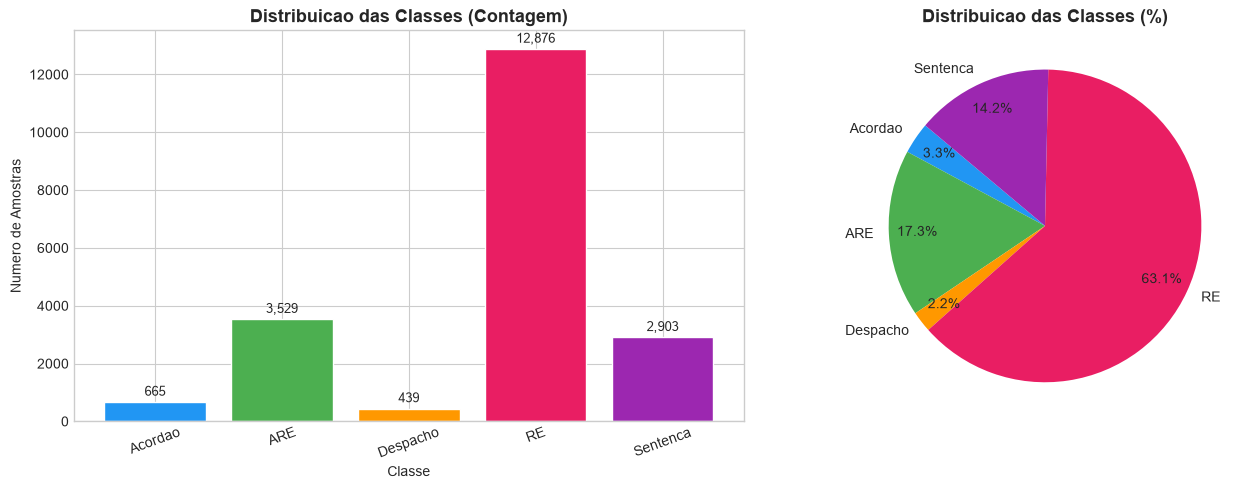

In [6]:
distribuicao = calcular_distribuicao_classes(df_treino_analise, incluir_rotulos_invalidos=True)
print("Distribuicao de Classes (treino):")
display(distribuicao)
plotar_distribuicao_classes(distribuicao)

### 1.5. Comprimento dos Textos

Esta seção tem como objetivo analisar a extensão dos documentos textuais presentes no conjunto de dados. Foram calculadas estatísticas descritivas referentes à quantidade de tokens (palavras) tanto no escopo global quanto divididas por categoria, incluindo métricas como média, mediana, desvio padrão e valores extremos. Desse modo será possível identificar outliers, como documentos quase vazios ou muito longos, e auxiliar nas decisões de pré-processamento.

Estatisticas Gerais de Comprimento:


,quantidade_documentos,media_tokens,mediana_tokens,desvio_padrao_tokens,minimo_tokens,maximo_tokens,percentil_90_tokens,percentil_95_tokens
0,20412,216.245934,209.0,92.824114,0,844,327.0,380.0



Estatisticas por Classe (tokens):


,Category,quantidade_documentos,media_tokens,mediana_tokens,desvio_padrao_tokens,minimo_tokens,maximo_tokens,nome_classe
0,0,665,251.539850,262.0,114.338256,19,576,Acordao
1,1,3529,195.198923,181.0,90.093587,0,685,ARE
2,2,439,149.036446,152.0,102.660404,14,844,Despacho
3,3,12876,213.882883,206.0,87.938303,4,781,RE
4,4,2903,254.391319,243.0,94.121400,13,837,Sentenca


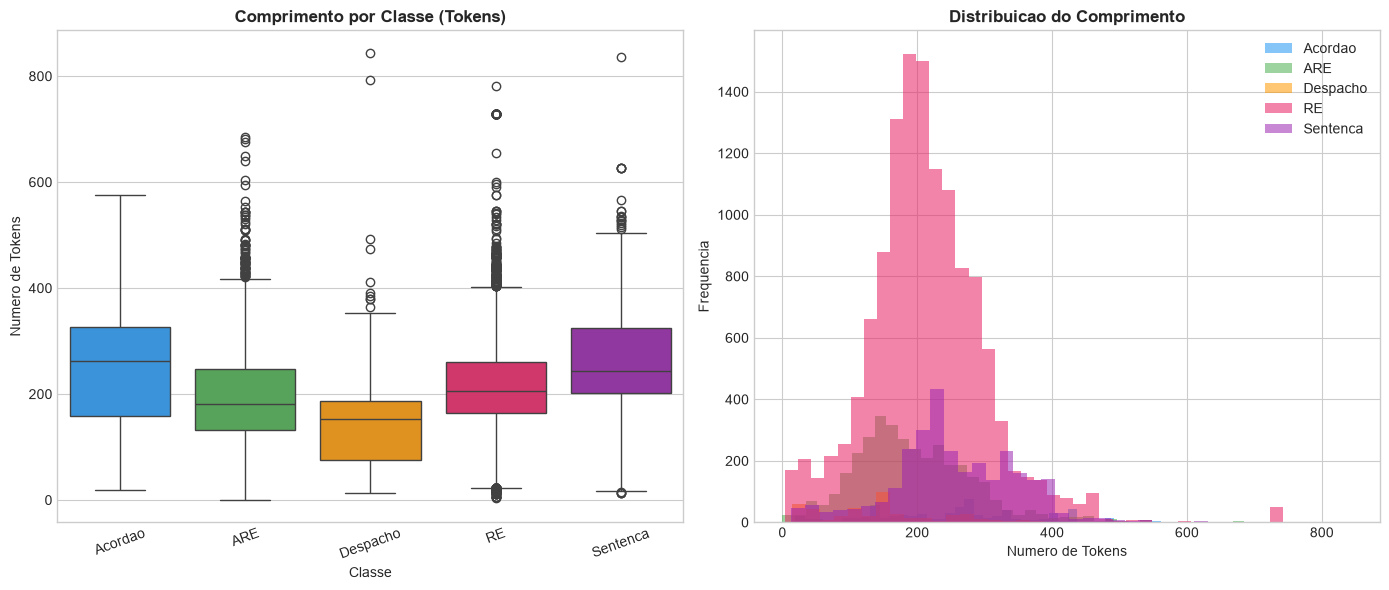

In [7]:
df_validos = filtrar_rotulos_validos(df_treino_analise)

stats_gerais = calcular_estatisticas_tamanho_textos(df_validos)
print("Estatisticas Gerais de Comprimento:")
display(stats_gerais)

stats_por_classe = calcular_estatisticas_tamanho_por_classe(df_validos)
print("\nEstatisticas por Classe (tokens):")
display(stats_por_classe)

plotar_comprimento_textos(df_validos)

### 1.6. Palavras Mais Frequentes e Nuvem de Palavras

Esta seção tem como objetivo explorar o vocabulário no conjunto de dados e destacar os termos mais frequentes de cada categoria. Além disso, foram geradas representações visuais, como gráficos de barras e nuvens de palavras. 


CLASSE 0: ACORDAO


,classe,nome_classe,palavra,frequencia
0,0,Acordao,recurso,1041
1,0,Acordao,federal,1041
2,0,Acordao,parte,938
3,0,Acordao,turma,854
4,0,Acordao,valor,813
5,0,Acordao,relator,652
6,0,Acordao,pagamento,627
7,0,Acordao,julgamento,621
8,0,Acordao,autos,603
9,0,Acordao,juiz,589



CLASSE 1: ARE


,classe,nome_classe,palavra,frequencia
20,1,ARE,recurso,7294
21,1,ARE,federal,4951
22,1,ARE,geral,2907
23,1,ARE,agravo,2834
24,1,ARE,direito,2790
25,1,ARE,tribunal,2631
26,1,ARE,constitucional,2605
27,1,ARE,presente,2235
28,1,ARE,turma,2141
29,1,ARE,especial,2025



CLASSE 2: DESPACHO


,classe,nome_classe,palavra,frequencia
40,2,Despacho,recurso,1426
41,2,Despacho,agravo,917
42,2,Despacho,federal,743
43,2,Despacho,recursal,677
44,2,Despacho,turma,654
45,2,Despacho,tribunal,568
46,2,Despacho,autos,427
47,2,Despacho,desta,425
48,2,Despacho,processo,395
49,2,Despacho,interposto,385



CLASSE 3: RE


,classe,nome_classe,palavra,frequencia
60,3,RE,federal,19590
61,3,RE,geral,16238
62,3,RE,fazenda,16032
63,3,RE,procuradoria,14611
64,3,RE,nacional,14147
65,3,RE,recurso,13734
66,3,RE,direito,11312
67,3,RE,constitucional,11182
68,3,RE,servidores,8716
69,3,RE,tribunal,8417



CLASSE 4: SENTENCA


,classe,nome_classe,palavra,frequencia
80,4,Sentenca,federal,4042
81,4,Sentenca,servidores,3568
82,4,Sentenca,parte,3559
83,4,Sentenca,valor,3143
84,4,Sentenca,data,2643
85,4,Sentenca,desempenho,2498
86,4,Sentenca,gdpst,2422
87,4,Sentenca,partir,2405
88,4,Sentenca,rel,2258
89,4,Sentenca,direito,2196


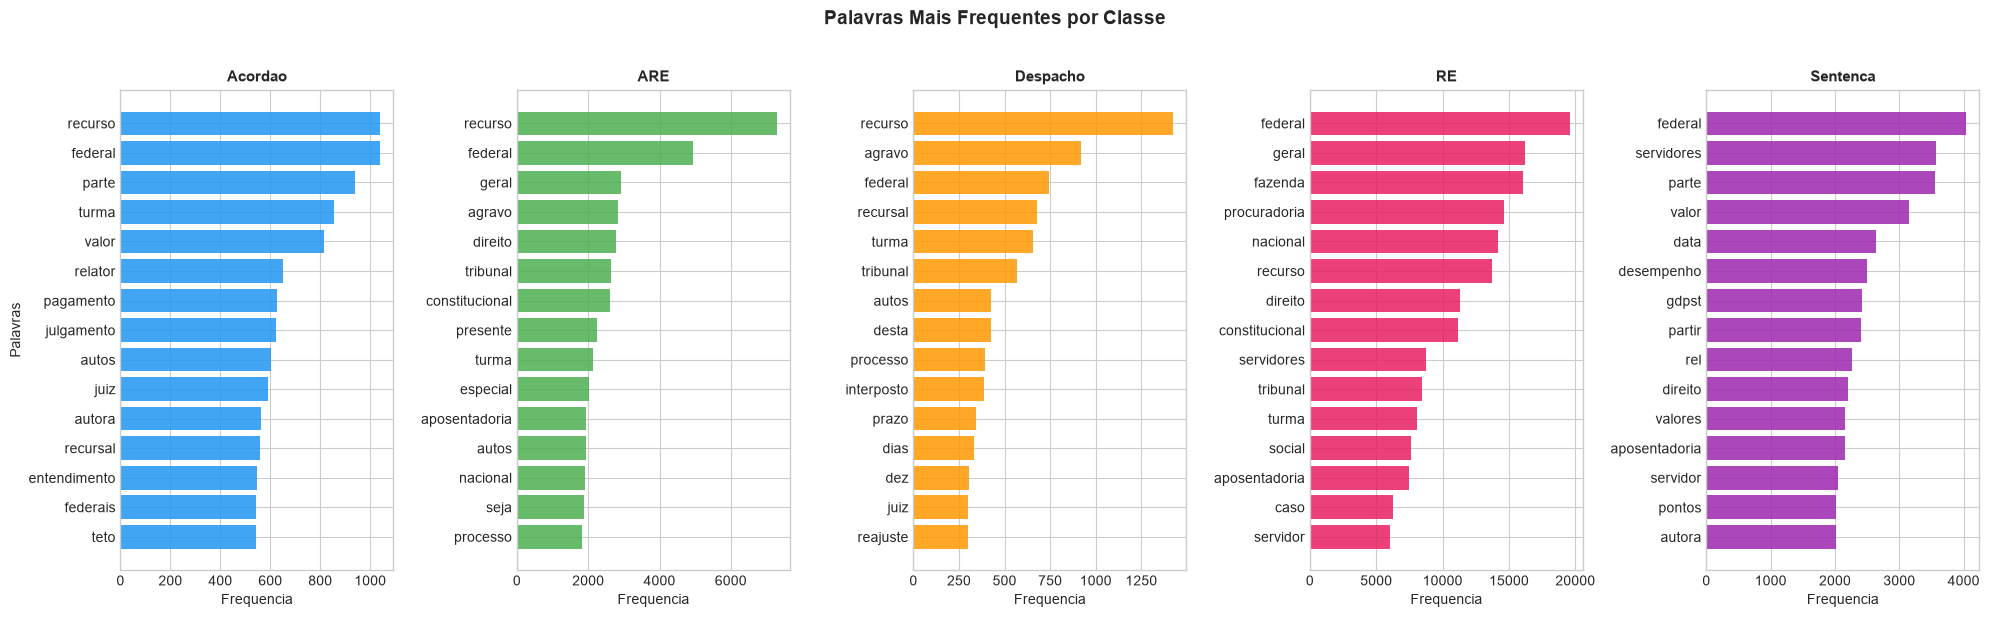

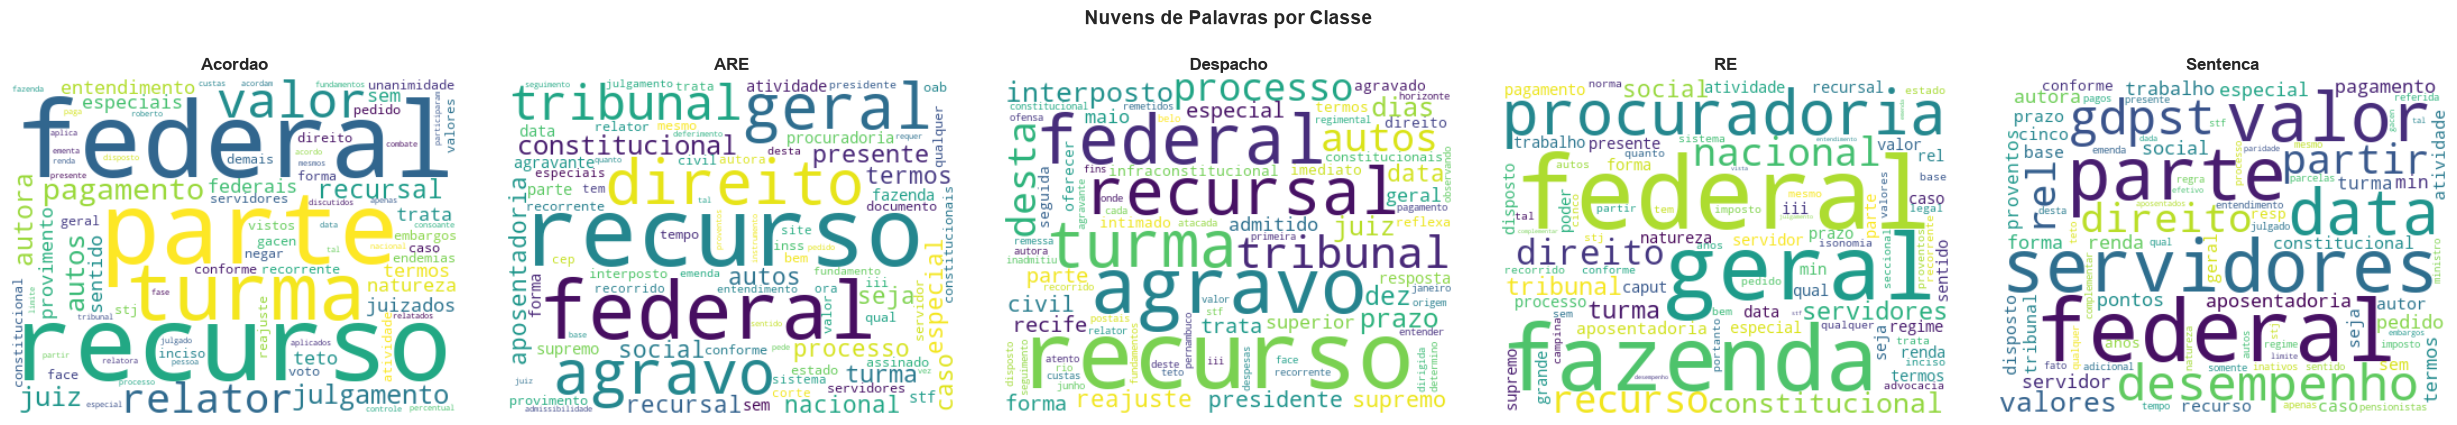

In [8]:
df_freq = calcular_palavras_frequentes_por_classe(df_validos, top_n=20)
for classe_id, grupo in df_freq.groupby('classe'):
    nome_classe = grupo['nome_classe'].iloc[0]
    print(f"\n{'='*40}")
    print(f"CLASSE {classe_id}: {nome_classe.upper()}")
    print(f"{'='*40}")
    display(grupo)

freq_dict = converter_para_dict_frequencias(df_freq, n_palavras=15)
plotar_palavras_frequentes(freq_dict, n_palavras=15)

plotar_nuvem_palavras(df_validos)

In [9]:
vocab_global = analisar_vocabulario(df_validos)


Analise de Vocabulario (corpus rotulado):
  Tipos unicos (vocab total) :   30,441
  Total de tokens            : 2,563,900
  Tokens com freq >= 5       :   12,661
  Tokens com freq >= 10      :    9,424

Top 20 palavras mais frequentes (geral):
  federal                          30,367
  recurso                          24,945
  geral                            21,051
  fazenda                          18,265
  nacional                         17,139
  direito                          16,835
  procuradoria                     16,246
  constitucional                   15,792
  servidores                       13,820
  tribunal                         13,265
  turma                            13,177
  aposentadoria                    11,762
  parte                            11,406
  social                           11,341
  especial                          9,717
  forma                             9,716
  caso                              9,678
  seja                              9,54

### 1.7. Constatações

1) **Distribuição das categorias**<br>
O conjunto de treinamento é fortemente desbalanceado. A classe RE representa a maioria do *dataset* (aproximadamente 57% das amostras), enquanto as classes Acordão (cerca de 3%) e Despacho (menos de 2%) são consideradas categorias raras. Também verificou-se que 10% do conjunto de dados (2.268 amostras) consistem em rótulos inválidos (-1).<br>
<u><b>Conclusão</b></u>: Foi identificada a necessidade de realizar a limpeza das amostras sem rótulo. Devido à assimetria dos dados, será necessário o uso de técnicas para diminuir o desbalanceamento, como a aplicação de pesos de classe, além da adoção da métrica **F1-Macro** como principal critério de avaliação dos modelos.

2) **Grande variabilidade no tamanho dos documentos em geral**<br>
As estatísticas descritivas e os gráficos de distribuição (histogramas e *boxplots*) evidenciaram uma variação extrema na extensão dos textos. O *dataset* abrange documentos quase vazios (mínimo de 1 *token*) até textos massivos (máximo de 8.443 *tokens*). Apesar da média geral estar em torno de 216 palavras, a presença de uma grande quantidade de *outliers* aumenta a cauda da distribuição.<br>
<u><b>Conclusão</b></u>: A alta amplitude mostra a importância da definição de um limite de truncamento (`max_len`) para preservar a informação na maioria dos documentos e otimizar o desempenho de algoritmos sequenciais (como BiLSTM e BERT).

3) **Diferenças de tamanho entre categorias**<br>
A quebra do comprimento por classe revelou alguns comportamentos estruturais. Documentos da categoria Despacho tendem a ser consideravelmente mais curtos (mediana de 152 palavras), enquanto Acordãos e Sentenças apresentam textos mais longos (médias ultrapassando 250 palavras).<br>
<u><b>Conclusão</b></u>: O tamanho do documento possui alto poder discriminativo. Essa variável pode ser extraída como uma *feature* auxiliar para os modelos clássicos. Além disso, o limite de truncamento textual precisa levar em conta a estrutura mais extensa de Acordãos e Sentenças.

4) **Vocabulário amplo e especializado**<br>
A análise lexical confirmou um vocabulário primário superior a 30 mil tipos únicos, inseridos num total de mais de 2,5 milhões de *tokens*. Observou-se o domínio do jargão do meio jurídico ("federal", "recurso", "geral", "fazenda", "procuradoria").<br>
<u><b>Conclusão</b></u>: Métodos de representação textual que consigam priorizar a relevância de termos dentro do domínio (como TF-IDF) ou capturar o contexto da linguagem jurídica tendem a superar abordagens baseadas apenas em contagem simples.

5) **Existência de vocabulário característico por categoria**<br>
As frequências e nuvens de palavras mostraram dois cenários diferentes. As classes de ARE e RE possuem grande sobreposição semântica, dividindo os mesmos termos mais frequentes. Em contrapartida, Despacho tem um vocabulário específico relacionado ao tempo ("prazo", "dias", "dez") e Sentença reflete uma presença de termos relacionados a pagamentos ("gdpst", "pagamento", "valores").<br>
<u><b>Conclusão</b></u>: Pode-se identificar uma separação de temas em categorias como Despacho e Sentença. Porém, a alta semelhança de vocabulários entre ARE e RE mostra uma possível zona de confusão dos algoritmos preditivos na distinção entre essas categorias.

6) **Problemas de codificação textual**<br>
Foi identificada a ocorrência de caracteres incorretamente codificados em diversos documentos, produzindo expressões como: "constituiÃ§Ã£o", "decisÃ£o". Esse problema, presente em 99,84% dos documentos (22.644 amostras), aumenta o tamanho do vocabulário e introduz ruídos nas representações textuais.<br>
<u><b>Conclusão</b></u>: Será aplicada uma correção de codificação para reduzir ruídos e melhorar a qualidade das representações linguísticas.

7) **Documentos duplicados**<br>
Observou-se uma alta taxa de documentos repetidos: 11.183 documentos duplicados, representando quase metade (49,31%) de todo o conjunto de treinamento.<br>
<u><b>Conclusão</b></u>: Será aplicada uma etapa de remoção de duplicatas para evitar superajuste (*overfitting*) sobre padrões repetitivos e melhorar a capacidade de generalização em novos textos.

---
## 2. Pre-processamento

A etapa de pré-processamento tem como objetivo transformar os dados textuais brutos em uma representação estruturada, limpa e adequada para o treinamento dos modelos, que será realizado na etapa seguinte. Utilizando as conclusões constatadas na etapa anterior de Análise Exploratória, esta fase atua diminuindo os ruídos identificados e destacando as características mais discriminativas do corpus, garantindo que os algoritmos foquem nos padrões linguísticos relevantes. Para tanto, foram aplicados os seguintes processos: higienização, padronização, truncamento, tratamento linguístico e engenharia de atributos. 
Ao final desta etapa, o esperado é que o conjunto de dados tenha apenas atributos consistentes e que maximizem a capacidade preditiva dos algoritmos. 

### 2.1. Carregamento do modelo spaCy

In [10]:
try:
    nlp = carregar_modelo_spacy('pt_core_news_lg')
    print(f"Modelo spaCy carregado: pt_core_news_lg")
except OSError:
    print("Modelo pt_core_news_lg nao encontrado.")
    nlp = None

Modelo spaCy carregado: pt_core_news_lg


### 2.2. Demonstração das etapas de limpeza

Foi isolada uma amostra do texto bruto para ilustrar cada transformação aplicada no processo de higienização, são elas:
 * Extração estrutural (extrair_texto_json): remoção de caracteres de formatação, mantendo apenas o conteúdo textual de interesse.
 * Restauração de Codificação (corrigir_encoding e normalizar_unicode): padronização de caracteres e correção de erros de grafia oriundos de termos corrompidos da base original.
 * Limpeza e Tokenização (limpar_ruido_ocr e tokenizar_texto): conversão do texto em uma lista de tokens, padronizadas em letras minúsculas e livres de pontuações.
 * Filtragem de Semântica (remover_stopwords_tokens): eliminação de termos funcionalmente vazios.
 * Redução Morfológica (lematizar_tokens): uso do spaCy para reduzir os termos à sua raizo, importante para unificar o vocabulário, especialmente variações como plurais e conjugações verbais.

In [11]:
exemplo_bruto = df_treino['Body'].iloc[0]
print("=== TEXTO BRUTO (primeiros 300 chars) ===")
print(exemplo_bruto[:300])
print()

# Extração do texto JSON e aplicação de etapas de limpeza e correção
t1 = extrair_texto_json(exemplo_bruto)
print("=== APOS extrair_texto_json ===")
print(t1[:300])
print()

# Demais limpezas
t2 = corrigir_encoding(t1)
t3 = normalizar_unicode(t2)
t4 = limpar_ruido_ocr(t3)
tokens = tokenizar_texto(t4, converter_minusculas=True)

# Remoção de stopwords
tokens_sem_sw = remover_stopwords_tokens(tokens)

print("=== TOKENS APOS remocao de stopwords (primeiros 30) ===")
print(tokens_sem_sw[:30])

# Lematização
if nlp is not None:
    tokens_lem = lematizar_tokens(tokens_sem_sw, nlp=nlp)
    tokens_lem = remover_stopwords_tokens(tokens_lem)
    print("\n=== TOKENS APOS LEMATIZACAO (primeiros 30) ===")
    print(tokens_lem[:30])

=== TEXTO BRUTO (primeiros 300 chars) ===
{"conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido conhecido provido fim que seja anulado v acÃ³rdÃ£o impugnado assim nÃ£o entender que seja inteiramente reformado por violaÃ§Ã£o flagrante aos disp

=== APOS extrair_texto_json ===
conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido conhecido provido fim que seja anulado v acÃ³rdÃ£o impugnado assim nÃ£o entender que seja inteiramente reformado por violaÃ§Ã£o flagrante aos dispos

=== TOKENS APOS remocao de stopwords (primeiros 30) ===
['conclusão', 'diante', 'exposto', 'recorrente', 'espera', 'confia', 'recurso', 'ora', 'arrazoado', 'interposto', 'fulcro', 'artigo102', 'iii', 'constituição', 'federal', 'admitido', 'conhecido', 'provido', 'fim', 'anulado', 'acórdão', 'impugnado', 'assim', 'entende

### 2.3. Aplicação de limpeza no dataset inteiro

Após a visualização das etapas individuais de higienização, esta seção aplica as etapas de limpeza citadas anteriormente a toda a base de dados (conjuntos de treinamento e teste). Nesta etapa foram excluídas as amostras não rotuladas (Category == -1) e os documentos duplicados com base no texto bruto (Body). Depois dessas exclusões e da aplicação das etapas mencionadas na seção anterior, foram descartados documentos que se tornaram vazios, ou seja, que possuíam zero tokens válidos devido à remoção de ruídos e stopwords. Ao final da execução, o corpus é consolidado em uma versão limpa e estruturada, estabelecendo a base que será utilizada nas etapas seguintes. 

In [12]:
# Remoção de rótulos inválidos
df_treino_valido = df_treino[df_treino['Category'] >= 0].copy()
print(f"Removidos {len(df_treino) - len(df_treino_valido):,} rótulos inválidos (-1).")

# Remoção de duplicatas
df_treino_valido2 = remover_documentos_duplicados(df_treino_valido, coluna='Body')
print(f"Removidos {len(df_treino_valido) - len(df_treino_valido2):,} documentos duplicados.")

# Preprocessa o treino 
df_treino_proc = aplicar_pipeline(
    df_treino_valido2, coluna='Body',
    nlp=nlp,
    lematizar=True,
    verbose=True,
)

# Remoção de textos que zeraram a quantidade de tokens após as limpezas
df_rot = remover_textos_vazios(df_treino_proc, coluna='texto_preprocessado').reset_index(drop=True)
print(f"Removidos {len(df_treino_proc) - len(df_rot):,} documentos vazios.")

# Remoção de duplicatas novamente, pois documentos podem ter se tornado iguais após limpezas
df_rot = df_rot.drop_duplicates(subset=['texto_preprocessado']).reset_index(drop=True)

print(f"\nAmostras limpas disponíveis para treinamento: {len(df_rot):,}")

# Preprocessa conjunto de teste
df_teste_proc = aplicar_pipeline(
    df_teste, coluna='Body',
    nlp=nlp,
    lematizar=True,
    verbose=True,
)

display(df_rot[['Body', 'texto_preprocessado', 'Category']].head(3))

Removidos 2,268 rótulos inválidos (-1).
Removidos 9,843 documentos duplicados.
Preprocessando 10,569 textos (com lematizacao (spaCy))...
   2,000 / 10,569 processados
   4,000 / 10,569 processados
   6,000 / 10,569 processados
   8,000 / 10,569 processados
  10,000 / 10,569 processados
Preprocessamento concluido.
Removidos 1 documentos vazios.

Amostras limpas disponíveis para treinamento: 10,540
Preprocessando 2,521 textos (com lematizacao (spaCy))...
   2,000 / 2,521 processados
Preprocessamento concluido.


,Body,texto_preprocessado,Category
0,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fu...",conclusão diante expor recorrente esperar confiar recurso ora arrazoar interposto fulcro artigo1...,3
1,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ...",artigo55 gecen gacen devir titular emprego cargo público tratar artigo53 de este lei caráter per...,3
2,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o disc...",seguir desacrir decisão negar seguimento recurso extraordinário equívoco decisão discutir consti...,1


### 2.4. Verificação de ruídos

Após a aplicação de etapas da limpeza, os documentos, agora filtrados, foram verificados novamente para atestar que agora estão livres de ruídos e demais problemas. 

In [13]:
verificar_ruidos_dataset(df_rot, coluna_texto='texto_preprocessado', coluna_alvo='Category')

=== VERIFICAÇÃO DE RUÍDOS NO DATASET PÓS-PROCESSAMENTO ===

1. Documentos nulos (NaN): 0
2. Documentos totalmente vazios (''): 0
3. Rótulos inválidos (Category < 0): 0
4. Duplicatas no texto processado: 0

5. Estatísticas de comprimento (tokens):
   - Mínimo de tokens em um documento: 3
   - Máximo de tokens em um documento: 687
   - Documentos com menos de 3 tokens úteis: 0

Dataset limpo e estruturado.


### 2.5. Demonstração de POS Tagging, NER e Análise por Classe
Nesta seção são extraídas características linguísticas para enriquecer a representação matemática dos documentos, são elas:
 * **POS Tagging (Anotação Morfossintática)**: classifica a categoria gramatical de cada termo. Como textos jurídicos possuem alta quantidade de substantivos (NOUN) e nomes próprios (PROPN), entender a proporção dessas classes permite que o modelo capture a estrutura de cada tipo de documento.
 * **NER (Reconhecimento de Entidades) e Referências**: foi adotado o modelo `pt_core_news_lg` do spaCy para português. Diferentemente do `pt_core_news_sm`, essa versão possui maior cobertura lexical e apresenta melhor desempenho na análise linguística, lematização, POS Tagging e reconhecimento de entidades nomeadas. Essa extração é combinada com o uso de expressões regulares (regex) para capturar referências a leis e dispositivos legais.


In [14]:
if nlp is not None:
    # POS tagging: exemplo 
    print("=== POS Tagging (exemplo) ===")
    exemplo_proc = df_rot['texto_preprocessado'].iloc[0]
    pares_pos = aplicar_pos_tagging(exemplo_proc[:500], nlp=nlp)
    for token, pos, tag in pares_pos[:20]:
        print(f"  {token:<20} {pos:<8} {tag}")

    # NER: exemplo 
    print("\n=== NER (exemplo) ===")
    entidades = extrair_entidades_nomeadas(exemplo_proc[:1000], nlp=nlp)
    for ent in entidades[:10]:
        print(f"  [{ent['tipo']}] {ent['texto']}")

    # Menções legais via regex: exemplo 
    print("\n=== Mencoes legais via regex (exemplo) ===")
    mencoes = extrair_mencoes_legais(exemplo_proc[:2000], nlp=nlp)
    display(pd.DataFrame([mencoes]))
else:
    print("spaCy nao disponivel.")

=== POS Tagging (exemplo) ===
  conclusão            NOUN     NOUN
  diante               ADV      ADV
  expor                VERB     VERB
  recorrente           ADV      ADV
  esperar              VERB     VERB
  confiar              VERB     VERB
  recurso              NOUN     NOUN
  ora                  ADV      ADV
  arrazoar             X        X
  interposto           VERB     VERB
  fulcro               ADJ      ADJ
  artigo102            VERB     VERB
  iii                  ADP      ADP
  constituição         NOUN     NOUN
  federal              ADJ      ADJ
  admitir              VERB     VERB
  conhecer             VERB     VERB
  provir               NOUN     NOUN
  fim                  SCONJ    SCONJ
  anular               VERB     VERB

=== NER (exemplo) ===
  [PER] alexandre simões camara silva

=== Mencoes legais via regex (exemplo) ===


,entidades_spacy,mencoes_legais_regex
0,[alexandre simões camara silva],[artigo102]


### 2.6. Aplicação de POS Tagging, NER e Análise por Classe no dataset inteiro


NER - top entidades em 800 amostras:
  PER       :  1933  | ex: alexandre simões camara silva, gecen gacen, gacen
  ORG       :  1228  | ex: stf, stf, fazenda nacional
  LOC       :   811  | ex: campino grande, lazzari, campina grande
  MISC      :   245  | ex: artigo1, artigo2 artigo3, decreto7133

Proporcao de Tags POS por classe (amostra)


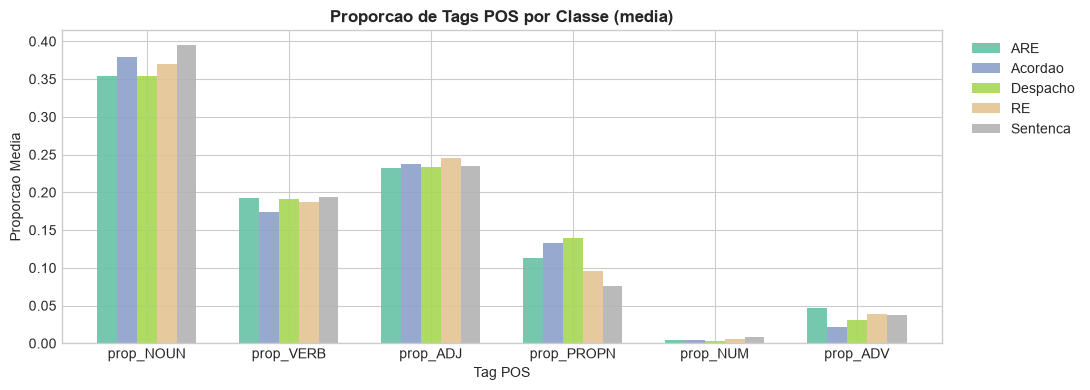

In [15]:
if nlp is not None:
    # NER em amostra do corpus
    textos_amostra = df_rot['texto_preprocessado'].values
    contagem_ner, exemplos_ner = aplicar_ner_juridico(textos_amostra, nlp=nlp, n_amostras=800)

    # POS Tagging: proporção média de classes em uma amostra
    print("\nProporcao de Tags POS por classe (amostra)")
    df_pos_features = extrair_features_pos(df_rot, nlp=nlp, coluna='texto_preprocessado', amostra=800)
    plotar_distribuicao_pos(df_pos_features)

else:
    print("Análises POS e NER indisponíveis (spaCy não carregado).")

---
## 3. Experimentos

Protocolo experimental:
- **Divisao dos dados**: 80% para treino e para 20% validacao estratificada (mantem proporcao de classes).
- **Metrica principal**: F1-Macro — penaliza igualmente erros em classes raras e dominantes.
- **Representacoes utilizadas**: TF-IDF esparsa utilizando 50k features e unigrams + bigrams, TF-IDF + NER + POS  e Word2Vec CBOW 100 dimensões.
- **Comparacao entre representacoes**: alem de avaliar qualidade, também é avaliado quanto tempo cada abordagem leva para gerar representação dos textos, treinar o modelo e fazer predições na validação.
- **Modelos Classicos**: LR, SVM (com calibracao Platt) e NB (Laplace alpha=1), testado também com a validação cruzada 5-fold sem data leakage e com NER + POS e aplicado apenas em LR e SVM
- **Modelo Profundo**: BiLSTM com atencao (2 camadas, weighted loss, grad clipping, LR scheduler) `**#######YUGO MUDAR#########**`
- **Transformer**: fine-tuning BERTimbau (early stopping, fp16 GPU, warmup)

In [16]:
# 3.1 Divisao treino/validacao estratificada
from sklearn.model_selection import train_test_split

# Mantem o DataFrame alinhado para permitir features adicionais (ex.: NER) por documento.
df_modelagem = df_rot.reset_index(drop=True).copy()
df_tr_modelo, df_vl_modelo = train_test_split(
    df_modelagem,
    test_size=0.2,
    random_state=SEED,
    stratify=df_modelagem['Category'],
)

X_treino_txt      = np.array(df_tr_modelo['texto_preprocessado'].tolist())
X_validacao_txt      = np.array(df_vl_modelo['texto_preprocessado'].tolist())
X_texto       = np.array(df_modelagem['texto_preprocessado'].tolist())
X_teste_texto = np.array(df_teste_proc['texto_preprocessado'].tolist())

y_tr = df_tr_modelo['Category'].to_numpy().astype(int)
y_vl = df_vl_modelo['Category'].to_numpy().astype(int)
y    = df_modelagem['Category'].to_numpy().astype(int)

# Textos menos processados para NER: preservam capitalizacao, pontuacao e padroes legais.
X_treino_ner_raw  = np.array(df_tr_modelo['Body'].tolist())
X_validacao_ner_raw  = np.array(df_vl_modelo['Body'].tolist())
X_teste_ner_raw = np.array(df_teste_proc['Body'].tolist())

print(f"Treino   : {len(X_treino_txt):,} amostras")
print(f"Validacao: {len(X_validacao_txt):,} amostras")
print(f"Teste    : {len(X_teste_texto):,} amostras")
print(f"\nDistribuicao treino: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Distribuicao val  : {dict(zip(*np.unique(y_vl, return_counts=True)))}")

Treino   : 8,432 amostras
Validacao: 2,108 amostras
Teste    : 2,521 amostras

Distribuicao treino: {0: 256, 1: 2042, 2: 195, 3: 4599, 4: 1340}
Distribuicao val  : {0: 64, 1: 511, 2: 49, 3: 1149, 4: 335}


#### 3.2 Representacao TF-IDF, NER, POS e Modelos Classicos

**TF-IDF** utilizando unigrams + bigrams para capturar expressoes juridicas importantes.
`sublinear_tf=True` suaviza palavras muito frequentes, para evitar que elas dominem a classificacao.  
**NER + POS** entram como complemento numerico ao TF-IDF: entidades (`PER`, `ORG`, `LOC`, `MISC`), mencoes legais e proporcoes gramaticais (`NOUN`, `VERB`, `ADJ`, `PROPN`, `NUM`, `ADV`) por documento.  
Essa combinacao e mais adequada para **Regressao Logistica** e **SVM**, pois ambos lidam bem com atributos esparsos de texto mais atributos numericos escalados.  
**Naive Bayes** permanece apenas com TF-IDF, porque sua premissa multinomial combina melhor com contagens/frequencias nao-negativas do texto.

In [17]:
from time import perf_counter

from scipy import sparse
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

# Dicionarios para comparacao de tempo entre representacoes/modelos
tempos_representacoes = {}
tempos_modelos = {}

# Vetorizacao TF-IDF
inicio = perf_counter()
vet_tfidf, X_treino_tfidf, X_validacao_tfidf, X_teste_tfidf = vetorizar_tfidf(
    X_treino_txt, X_validacao_txt, X_teste_texto,
    max_features=50000, ngram_range=(1, 2),
)
tempo_tfidf_vetorizacao = perf_counter() - inicio

# MaxAbsScaler para Naive Bayes (evita problemas com frequencias altas e preserva esparsidade)
inicio = perf_counter()
scaler_nb = MaxAbsScaler()
X_treino_nn = scaler_nb.fit_transform(X_treino_tfidf)
X_validacao_nn = scaler_nb.transform(X_validacao_tfidf)
X_teste_nn = scaler_nb.transform(X_teste_tfidf)
tempo_tfidf_preparo_nb = perf_counter() - inicio

tempos_representacoes['TF-IDF'] = {
    'tempo_representacao_s': tempo_tfidf_vetorizacao,
    'tempo_preparo_nb_s': tempo_tfidf_preparo_nb,
}

print(f"TF-IDF vetorizado em {tempo_tfidf_vetorizacao:.2f}s | treino: {X_treino_tfidf.shape} | val: {X_validacao_tfidf.shape}")

# ---------- Features NER + POS do script de experimentos ----------
COLUNAS_LING_MODELO = [
    'ner_n_entidades',
    'ner_ent_por_100_tokens',
    'ner_n_mencoes_legais',
    'ner_tem_mencao_legal',
    'ner_prop_PER',
    'ner_prop_ORG',
    'ner_prop_LOC',
    'ner_prop_MISC',
    'pos_prop_NOUN',
    'pos_prop_VERB',
    'pos_prop_ADJ',
    'pos_prop_PROPN',
    'pos_prop_NUM',
    'pos_prop_ADV',
]

inicio = perf_counter()
features_linguisticas_treino = extrair_features_linguisticas_modelo(
    df_tr_modelo,
    nlp=nlp,
    coluna='Body',
    limite_chars=5000,
)
features_linguisticas_validacao = extrair_features_linguisticas_modelo(
    df_vl_modelo,
    nlp=nlp,
    coluna='Body',
    limite_chars=5000,
)
features_linguisticas_teste = extrair_features_linguisticas_modelo(
    df_teste_proc,
    nlp=nlp,
    coluna='Body',
    limite_chars=5000,
)
tempo_ner_features = perf_counter() - inicio

# Garante alinhamento e ordem fixa de colunas no treino/validacao/teste
features_linguisticas_treino = features_linguisticas_treino.reindex(columns=COLUNAS_LING_MODELO, fill_value=0.0)
features_linguisticas_validacao = features_linguisticas_validacao.reindex(columns=COLUNAS_LING_MODELO, fill_value=0.0)
features_linguisticas_teste = features_linguisticas_teste.reindex(columns=COLUNAS_LING_MODELO, fill_value=0.0)

inicio = perf_counter()
scaler_ner = StandardScaler()
X_treino_ner_num = sparse.csr_matrix(scaler_ner.fit_transform(features_linguisticas_treino))
X_validacao_ner_num = sparse.csr_matrix(scaler_ner.transform(features_linguisticas_validacao))
X_teste_ner_num = sparse.csr_matrix(scaler_ner.transform(features_linguisticas_teste))

X_treino_tfidf_ner = sparse.hstack([X_treino_tfidf, X_treino_ner_num], format='csr')
X_validacao_tfidf_ner = sparse.hstack([X_validacao_tfidf, X_validacao_ner_num], format='csr')
X_teste_tfidf_ner = sparse.hstack([X_teste_tfidf, X_teste_ner_num], format='csr')
tempo_ner_concatenacao = perf_counter() - inicio

tempos_representacoes['TF-IDF + NER + POS'] = {
    'tempo_representacao_s': tempo_tfidf_vetorizacao + tempo_ner_features + tempo_ner_concatenacao,
    'tempo_ner_pos_features_s': tempo_ner_features,
}

print(
    f"Features NER+POS extraidas em {tempo_ner_features:.2f}s | "
    f"n_features: {len(COLUNAS_LING_MODELO)} | treino: {X_treino_tfidf_ner.shape}"
)
print("Resumo das features linguisticas (NER+POS) no treino:")
display(features_linguisticas_treino.describe().round(3))

print("--- Treinando modelos classicos ---")
print("\nRegressao Logistica (TF-IDF)")
inicio = perf_counter()
modelo_lr = treinar_regressao_logistica(X_treino_tfidf, y_tr, C=1.0)
tempo_lr_tfidf_treino = perf_counter() - inicio
tempos_modelos['LR (TF-IDF)'] = tempo_lr_tfidf_treino
tempos_representacoes['TF-IDF']['tempo_treino_lr_s'] = tempo_lr_tfidf_treino
print(f"Tempo de treino LR (TF-IDF): {tempo_lr_tfidf_treino:.2f}s")

print("\nSVM Linear com calibracao Platt (TF-IDF)")
inicio = perf_counter()
modelo_svm = treinar_svm_linear(X_treino_tfidf, y_tr, C=1.0, calibrar=True)
tempo_svm_tfidf_treino = perf_counter() - inicio
tempos_modelos['SVM (TF-IDF)'] = tempo_svm_tfidf_treino
print(f"Tempo de treino SVM (TF-IDF): {tempo_svm_tfidf_treino:.2f}s")

print("\nNaive Bayes Multinomial com Laplace smoothing (alpha=1)")
inicio = perf_counter()
modelo_nb = treinar_naive_bayes(X_treino_nn, y_tr, alpha=1.0)
tempo_nb_tfidf_treino = perf_counter() - inicio
tempos_modelos['NB (TF-IDF)'] = tempo_nb_tfidf_treino
print(f"Tempo de treino NB (TF-IDF): {tempo_nb_tfidf_treino:.2f}s")

print("\nRegressao Logistica (TF-IDF + NER + POS)")
inicio = perf_counter()
modelo_lr_ner = treinar_regressao_logistica(X_treino_tfidf_ner, y_tr, C=1.0)
tempo_lr_tfidf_ner_treino = perf_counter() - inicio
tempos_modelos['LR (TF-IDF + NER + POS)'] = tempo_lr_tfidf_ner_treino
tempos_representacoes['TF-IDF + NER + POS']['tempo_treino_lr_s'] = tempo_lr_tfidf_ner_treino
print(f"Tempo de treino LR (TF-IDF + NER + POS): {tempo_lr_tfidf_ner_treino:.2f}s")

print("\nSVM Linear com calibracao Platt (TF-IDF + NER + POS)")
inicio = perf_counter()
modelo_svm_ner = treinar_svm_linear(X_treino_tfidf_ner, y_tr, C=1.0, calibrar=True)
tempo_svm_tfidf_ner_treino = perf_counter() - inicio
tempos_modelos['SVM (TF-IDF + NER + POS)'] = tempo_svm_tfidf_ner_treino
print(f"Tempo de treino SVM (TF-IDF + NER + POS): {tempo_svm_tfidf_ner_treino:.2f}s")

print("\nModelos classicos treinados.")

  TF-IDF | vocab: 50,000 | features: 50,000
TF-IDF vetorizado em 17.33s | treino: (8432, 50000) | val: (2108, 50000)
Features NER+POS extraidas em 1177.31s | n_features: 14 | treino: (8432, 50014)
Resumo das features linguisticas (NER+POS) no treino:


,ner_n_entidades,ner_ent_por_100_tokens,ner_n_mencoes_legais,ner_tem_mencao_legal,ner_prop_PER,ner_prop_ORG,ner_prop_LOC,ner_prop_MISC,pos_prop_NOUN,pos_prop_VERB,pos_prop_ADJ,pos_prop_PROPN,pos_prop_NUM,pos_prop_ADV
count,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000
mean,4.592,2.612,3.020,0.832,0.397,0.251,0.245,0.051,0.326,0.155,0.186,0.085,0.005,0.047
std,3.541,2.522,2.675,0.374,0.317,0.291,0.270,0.135,0.043,0.034,0.041,0.084,0.010,0.022
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2.000,1.031,1.000,1.000,0.070,0.000,0.000,0.000,0.303,0.136,0.160,0.034,0.000,0.032
50%,4.000,1.946,2.000,1.000,0.375,0.167,0.200,0.000,0.329,0.156,0.184,0.060,0.000,0.047
75%,6.000,3.356,4.000,1.000,0.600,0.462,0.400,0.000,0.354,0.176,0.210,0.107,0.007,0.061
max,65.000,24.000,33.000,1.000,1.000,1.000,1.000,1.000,0.667,0.305,0.538,1.000,0.216,0.144


--- Treinando modelos classicos ---

Regressao Logistica (TF-IDF)
Tempo de treino LR (TF-IDF): 3.44s

SVM Linear com calibracao Platt (TF-IDF)
Tempo de treino SVM (TF-IDF): 72.80s

Naive Bayes Multinomial com Laplace smoothing (alpha=1)
Tempo de treino NB (TF-IDF): 0.21s

Regressao Logistica (TF-IDF + NER + POS)
Tempo de treino LR (TF-IDF + NER + POS): 6.31s

SVM Linear com calibracao Platt (TF-IDF + NER + POS)
Tempo de treino SVM (TF-IDF + NER + POS): 74.65s

Modelos classicos treinados.


#### 3.3 Validacao Cruzada Estratificada (5-fold)

A vetorizacao TF-IDF foi re-feita dentro de cada fold para evitar data leakage, o vocabulario foi aprendido apenas nos dados de treino de cada fold.
StratifiedKFold garante que a proporcao de classes seja mantida em cada divisao.

In [18]:
from sklearn.linear_model import LogisticRegression as rl
from sklearn.svm import LinearSVC as svm
from sklearn.naive_bayes import MultinomialNB as nb

print("Validacao Cruzada Estratificada (5-fold): ")
modelos_cv = {
    'Regressao Logistica': rl(C=1.0, max_iter=2000, class_weight='balanced',
                                solver='lbfgs', random_state=SEED),
    'SVM Linear'         : svm(C=1.0, class_weight='balanced',
                                 max_iter=3000, random_state=SEED),
    'Naive Bayes'        : nb(alpha=1.0),
}
resultados_cv = avaliar_validacao_cruzada(
    X_texto.tolist(), y, modelos_cv, n_splits=5, max_features=30000,
)

Validacao Cruzada Estratificada (5-fold): 
  Regressao Logistica                : F1-Macro = 0.8221 +/- 0.0085
  SVM Linear                         : F1-Macro = 0.8380 +/- 0.0101
  Naive Bayes                        : F1-Macro = 0.5945 +/- 0.0261


#### 3.4 Representacao Densa — Word2Vec CBOW

**Word2Vec CBOW** aprende vetores de palavras com base no contexto local em que elas aparecem.
Cada documento e representado pela media dos vetores de seus tokens (Bag-of-Embeddings).
Vetores conseguem capturar similaridades semanticas entre palavras que o TF-IDF esparso nao captura.

In [19]:
# Garante que o medidor de tempo de execucao esteja definido
try:
    perf_counter
except NameError:
    from time import perf_counter

# Garante que os dicionarios de tempos e modelos estejam definidos
try:
    tempos_representacoes
except NameError:
    tempos_representacoes = {}

try:
    tempos_modelos
except NameError:
    tempos_modelos = {}

inicio = perf_counter()

# Treina Word2Vec CBOW no corpus de treino rotulado
modelo_w2v = treinar_word2vec(
    X_treino_txt,
    dimensao=100, janela=5, min_count=2, epocas=10, sg=0,
)

# Embeddings medios
X_treino_emb = vetorizar_word2vec_media(X_treino_txt, modelo_w2v)
X_validacao_emb = vetorizar_word2vec_media(X_validacao_txt, modelo_w2v)
X_teste_emb = vetorizar_word2vec_media(X_teste_texto, modelo_w2v)

tempo_w2v_representacao = perf_counter() - inicio
tempos_representacoes['Word2Vec'] = {
    'tempo_representacao_s': tempo_w2v_representacao,
}

print(f"Embeddings | treino: {X_treino_emb.shape} | val: {X_validacao_emb.shape}")
print(f"Word2Vec + embeddings medios gerados em {tempo_w2v_representacao:.2f}s")

# LR sobre Word2Vec
inicio = perf_counter()
modelo_lr_w2v = treinar_regressao_logistica(X_treino_emb, y_tr, C=1.0, max_iter=2000)
tempo_lr_w2v_treino = perf_counter() - inicio
tempos_modelos['LR (Word2Vec)'] = tempo_lr_w2v_treino
tempos_representacoes['Word2Vec']['tempo_treino_lr_s'] = tempo_lr_w2v_treino

print(f"LR + Word2Vec treinado em {tempo_lr_w2v_treino:.2f}s.")

# SVM sobre Word2Vec
inicio = perf_counter()
modelo_svm_w2v = treinar_svm_linear(X_treino_emb, y_tr, C=1.0, calibrar=True)
tempo_svm_w2v_treino = perf_counter() - inicio
tempos_modelos['SVM (Word2Vec)'] = tempo_svm_w2v_treino
tempos_representacoes['Word2Vec']['tempo_treino_svm_s'] = tempo_svm_w2v_treino

print(f"SVM + Word2Vec treinado em {tempo_svm_w2v_treino:.2f}s.")

  Word2Vec | vocab: 16,689 | dim: 100
Embeddings | treino: (8432, 100) | val: (2108, 100)
Word2Vec + embeddings medios gerados em 24.08s
LR + Word2Vec treinado em 1.43s.
SVM + Word2Vec treinado em 14.15s.


#### 3.5 Comparacao de Tempo: TF-IDF vs TF-IDF+NER+POS vs Word2Vec

Esta comparacao mede o custo computacional das representacoes usadas nos modelos simples:

- `Tempo representacao (s)`: tempo para transformar textos em atributos.
- `Tempo treino LR (s)`: tempo para treinar a mesma Regressao Logistica sobre cada representacao.
- `Tempo predicao LR (s)`: tempo para predizer a validacao.
- `F1-Macro validacao`: qualidade obtida no conjunto de validacao.

A leitura principal e o compromisso entre velocidade e desempenho: TF-IDF e o baseline lexical; TF-IDF+NER+POS testa se entidades juridicas, mencoes legais e padroes gramaticais agregam sinal; Word2Vec testa uma representacao semantica densa.

In [20]:
from sklearn.metrics import f1_score

# Mede tambem o tempo de predicao na validacao para a comparacao ficar completa
tempos_predicao = {}

inicio = perf_counter()
preds_lr_tfidf_tempo = modelo_lr.predict(X_validacao_tfidf)
tempos_predicao['LR (TF-IDF)'] = perf_counter() - inicio

inicio = perf_counter()
preds_lr_w2v_tempo = modelo_lr_w2v.predict(X_validacao_emb)
tempos_predicao['LR (Word2Vec)'] = perf_counter() - inicio

linhas_comparacao = [
    {
        'Representacao': 'TF-IDF',
        'Modelo': 'Regressao Logistica',
        'Dimensoes treino': f"{X_treino_tfidf.shape[0]:,} x {X_treino_tfidf.shape[1]:,}",
        'Tempo representacao (s)': tempos_representacoes.get('TF-IDF', {}).get('tempo_representacao_s', np.nan),
        'Tempo treino LR (s)': tempos_modelos.get('LR (TF-IDF)', np.nan),
        'Tempo predicao LR (s)': tempos_predicao['LR (TF-IDF)'],
        'F1-Macro validacao': f1_score(y_vl, preds_lr_tfidf_tempo, average='macro'),
    },
]

if modelo_lr_ner is not None and X_validacao_tfidf_ner is not None:
    inicio = perf_counter()
    preds_lr_ner_tempo = modelo_lr_ner.predict(X_validacao_tfidf_ner)
    tempos_predicao['LR (TF-IDF + NER + POS)'] = perf_counter() - inicio
    linhas_comparacao.append({
        'Representacao': 'TF-IDF + NER + POS',
        'Modelo': 'Regressao Logistica',
        'Dimensoes treino': f"{X_treino_tfidf_ner.shape[0]:,} x {X_treino_tfidf_ner.shape[1]:,}",
        'Tempo representacao (s)': tempos_representacoes.get('TF-IDF + NER + POS', {}).get('tempo_representacao_s', np.nan),
        'Tempo treino LR (s)': tempos_modelos.get('LR (TF-IDF + NER + POS)', np.nan),
        'Tempo predicao LR (s)': tempos_predicao['LR (TF-IDF + NER + POS)'],
        'F1-Macro validacao': f1_score(y_vl, preds_lr_ner_tempo, average='macro'),
    })

linhas_comparacao.append({
    'Representacao': 'Word2Vec',
    'Modelo': 'Regressao Logistica',
    'Dimensoes treino': f"{X_treino_emb.shape[0]:,} x {X_treino_emb.shape[1]:,}",
    'Tempo representacao (s)': tempos_representacoes.get('Word2Vec', {}).get('tempo_representacao_s', np.nan),
    'Tempo treino LR (s)': tempos_modelos.get('LR (Word2Vec)', np.nan),
    'Tempo predicao LR (s)': tempos_predicao['LR (Word2Vec)'],
    'F1-Macro validacao': f1_score(y_vl, preds_lr_w2v_tempo, average='macro'),
})

comparacao_tempo_representacoes = pd.DataFrame(linhas_comparacao)
comparacao_tempo_representacoes['Tempo total LR (s)'] = (
    comparacao_tempo_representacoes['Tempo representacao (s)']
    + comparacao_tempo_representacoes['Tempo treino LR (s)']
    + comparacao_tempo_representacoes['Tempo predicao LR (s)']
)

colunas_tempo = [
    'Tempo representacao (s)',
    'Tempo treino LR (s)',
    'Tempo predicao LR (s)',
    'Tempo total LR (s)',
]
comparacao_tempo_representacoes[colunas_tempo] = comparacao_tempo_representacoes[colunas_tempo].round(3)
comparacao_tempo_representacoes['F1-Macro validacao'] = comparacao_tempo_representacoes['F1-Macro validacao'].round(4)

print("Comparacao direta entre representacoes usando o mesmo classificador (Regressao Logistica):")
display(comparacao_tempo_representacoes)

# Complemento: tempo de treino dos modelos classicos treinados sobre TF-IDF/TF-IDF+NER+POS
tabela_tempos_classicos = pd.DataFrame([
    {'Modelo': nome, 'Tempo treino (s)': tempo}
    for nome, tempo in tempos_modelos.items()
    if 'TF-IDF' in nome
]).sort_values('Tempo treino (s)')
tabela_tempos_classicos['Tempo treino (s)'] = tabela_tempos_classicos['Tempo treino (s)'].round(3)

print("\nTempos de treino dos modelos classicos com TF-IDF e TF-IDF+NER+POS:")
display(tabela_tempos_classicos)

mais_rapida = comparacao_tempo_representacoes.sort_values('Tempo total LR (s)').iloc[0]['Representacao']
melhor_f1 = comparacao_tempo_representacoes.sort_values('F1-Macro validacao', ascending=False).iloc[0]['Representacao']

print("\nLeitura executiva:")
print(f"- Representacao mais rapida no fluxo LR: {mais_rapida}")
print(f"- Melhor F1-Macro na validacao: {melhor_f1}")
if 'TF-IDF + NER + POS' in comparacao_tempo_representacoes['Representacao'].values:
    print("- TF-IDF + NER + POS mostra o ganho conjunto de entidades juridicas e sinais gramaticais.")

Comparacao direta entre representacoes usando o mesmo classificador (Regressao Logistica):


,Representacao,Modelo,Dimensoes treino,Tempo representacao (s),Tempo treino LR (s),Tempo predicao LR (s),F1-Macro validacao,Tempo total LR (s)
0,TF-IDF,Regressao Logistica,"8,432 x 50,000",17.332,3.437,0.283,0.8058,21.053
1,TF-IDF + NER + POS,Regressao Logistica,"8,432 x 50,014",1195.103,6.314,0.101,0.7925,1201.518
2,Word2Vec,Regressao Logistica,"8,432 x 100",24.084,1.431,0.007,0.5628,25.522



Tempos de treino dos modelos classicos com TF-IDF e TF-IDF+NER+POS:


,Modelo,Tempo treino (s)
2,NB (TF-IDF),0.214
0,LR (TF-IDF),3.437
3,LR (TF-IDF + NER + POS),6.314
1,SVM (TF-IDF),72.800
4,SVM (TF-IDF + NER + POS),74.647



Leitura executiva:
- Representacao mais rapida no fluxo LR: TF-IDF
- Melhor F1-Macro na validacao: TF-IDF
- TF-IDF + NER + POS mostra o ganho conjunto de entidades juridicas e sinais gramaticais.


# ` YUGO `

#### 3.5 BiLSTM com Mecanismo de Atencao

Rede Recorrente Bidirecional com atencao sobre os estados ocultos:
- **2 camadas BiLSTM** captura dependencias de longo alcance em ambas as direcoes
- **Atencao por softmax** pondera as posicoes mais informativas de cada sequencia
- **Weighted CrossEntropyLoss** corrige desbalanceamento de classes
- **Gradient clipping** (max_norm=1.0) estabiliza o treinamento
- **ReduceLROnPlateau** reduz LR automaticamente quando F1-Macro estagna

In [21]:
# modelo_bilstm, vocab_bilstm, historico_bilstm = None, None, None

# if EXECUTAR_BILSTM:
#     print("Treinando BiLSTM com Atencao...")
#     modelo_bilstm, vocab_bilstm, historico_bilstm = treinar_bilstm(
#         X_tr_txt, y_tr,
#         X_vl_txt, y_vl,
#         dim_embedding=128,
#         dim_oculto=256,
#         num_camadas=2,
#         dropout=0.4,
#         epocas=15,
#         tamanho_lote=32,
#         taxa_aprendizagem=1e-3,
#         comprimento_max=256,
#     )
#     print("BiLSTM treinado.")
# else:
#     print("EXECUTAR_BILSTM=False — pulando treinamento BiLSTM.")

#### 3.6 Fine-tuning BERTimbau (neuralmind/bert-base-portuguese-cased)

**BERTimbau** e um modelo BERT pre-treinado em corpus juridico brasileiro.
O fine-tuning adapta os pesos para classificacao de 5 classes com:
- **EarlyStopping** (patience=2 epocas, baseado em F1-Macro de validacao)
- **Warmup linear** (10% dos steps) + **Weight Decay** (regularizacao)
- **FP16** em GPU para acelerar o treinamento

In [22]:
# trainer_bert, tokenizador_bert = None, None

# if EXECUTAR_TRANSFORMER:
#     print("Fine-tuning BERTimbau...")
#     trainer_bert, tokenizador_bert = treinar_transformer(
#         X_tr_txt, y_tr,
#         X_vl_txt, y_vl,
#         nome_modelo='neuralmind/bert-base-portuguese-cased',
#         num_epocas=5,
#         tamanho_lote=16,
#         taxa_aprendizagem=2e-5,
#         diretorio_saida='resultados_transformer',
#         comprimento_max=128,
#     )
#     print("BERTimbau fine-tuned.")
# else:
#     print("EXECUTAR_TRANSFORMER=False — pulando fine-tuning.")

---
## 4. Analise dos Resultados

Comparacao sistematica dos modelos treinados:
- **4.1** — Metricas detalhadas por modelo e por classe
- **4.2** — Ranking geral (F1-Macro) com visualizacao comparativa
- **4.3** — Matrizes de confusao (absoluta + normalizada) dos melhores modelos
- **4.4** — Curvas de treinamento do BiLSTM (loss + F1-Macro por epoca)
- **4.5** — Teste de McNemar (significancia estatistica entre os dois melhores)
- **4.6** — Analise qualitativa dos erros do melhor modelo
- **4.7** — Geracao dos arquivos de submissao (Kaggle)

In [23]:
# 4.1 Predicoes na validacao + relatorios detalhados por modelo
lista_resultados = []
mapa_preds = {}  # para McNemar

# ---------- LR (TF-IDF) ----------
preds_lr = modelo_lr.predict(X_validacao_tfidf)
mapa_preds['LR (TF-IDF)'] = preds_lr
rel_lr = exibir_relatorio(y_vl, preds_lr, nome_modelo='Regressao Logistica (TF-IDF)')
lista_resultados.append(rel_lr)

# ---------- SVM (TF-IDF) ----------
preds_svm = modelo_svm.predict(X_validacao_tfidf)
mapa_preds['SVM (TF-IDF)'] = preds_svm
rel_svm = exibir_relatorio(y_vl, preds_svm, nome_modelo='SVM Linear (TF-IDF)')
lista_resultados.append(rel_svm)

# ---------- NB (TF-IDF) ----------
preds_nb = modelo_nb.predict(X_validacao_nn)
mapa_preds['NB (TF-IDF)'] = preds_nb
rel_nb = exibir_relatorio(y_vl, preds_nb, nome_modelo='Naive Bayes (TF-IDF)')
lista_resultados.append(rel_nb)

# ---------- LR (TF-IDF + NER + POS) ----------
if modelo_lr_ner is not None and X_validacao_tfidf_ner is not None:
    preds_lr_ner = modelo_lr_ner.predict(X_validacao_tfidf_ner)
    mapa_preds['LR (TF-IDF+NER+POS)'] = preds_lr_ner
    rel_lr_ner = exibir_relatorio(y_vl, preds_lr_ner, nome_modelo='Regressao Logistica (TF-IDF + NER + POS)')
    lista_resultados.append(rel_lr_ner)

# ---------- SVM (TF-IDF + NER + POS) ----------
if modelo_svm_ner is not None and X_validacao_tfidf_ner is not None:
    preds_svm_ner = modelo_svm_ner.predict(X_validacao_tfidf_ner)
    mapa_preds['SVM (TF-IDF+NER+POS)'] = preds_svm_ner
    rel_svm_ner = exibir_relatorio(y_vl, preds_svm_ner, nome_modelo='SVM Linear (TF-IDF + NER + POS)')
    lista_resultados.append(rel_svm_ner)

# ---------- LR (Word2Vec) ----------
preds_lrw2v = modelo_lr_w2v.predict(X_validacao_emb)
mapa_preds['LR (W2V)'] = preds_lrw2v
rel_lrw2v = exibir_relatorio(y_vl, preds_lrw2v, nome_modelo='LR + Word2Vec')
lista_resultados.append(rel_lrw2v)

# ---------- BiLSTM ----------
# if modelo_bilstm is not None:
#     preds_bilstm = predizer_bilstm(modelo_bilstm, X_validacao_txt, vocab_bilstm, comprimento_max=256)
#     mapa_preds['BiLSTM'] = preds_bilstm
#     rel_bilstm = exibir_relatorio(y_vl, preds_bilstm, nome_modelo='BiLSTM Atencao')
#     lista_resultados.append(rel_bilstm)

# # ---------- BERTimbau ----------
# if trainer_bert is not None:
#     preds_bert = predizer_transformer(trainer_bert, tokenizador_bert, X_validacao_txt, comprimento_maximo=128)
#     mapa_preds['BERTimbau'] = preds_bert
#     rel_bert = exibir_relatorio(y_vl, preds_bert, nome_modelo='BERTimbau')
#     lista_resultados.append(rel_bert)


RELATORIO: Regressao Logistica (TF-IDF)
              precision    recall  f1-score   support

     Acordao       0.66      0.81      0.73        64
         ARE       0.82      0.74      0.78       511
    Despacho       0.89      0.69      0.78        49
          RE       0.87      0.87      0.87      1149
    Sentenca       0.81      0.93      0.87       335

    accuracy                           0.84      2108
   macro avg       0.81      0.81      0.81      2108
weighted avg       0.85      0.84      0.84      2108

  F1-Macro    : 0.8058   <- metrica principal
  F1-Weighted : 0.8427
  Acuracia    : 0.8435

RELATORIO: SVM Linear (TF-IDF)
              precision    recall  f1-score   support

     Acordao       0.81      0.66      0.72        64
         ARE       0.86      0.71      0.78       511
    Despacho       0.92      0.71      0.80        49
          RE       0.85      0.93      0.89      1149
    Sentenca       0.89      0.92      0.90       335

    accuracy        

#### 4.2 Ranking Geral dos Modelos


Comparacao de Modelos (ordenado por F1-Macro):
                                          f1_macro  f1_weighted  accuracy  precision_macro  recall_macro
modelo                                                                                                  
SVM Linear (TF-IDF)                         0.8199       0.8582    0.8615           0.8668        0.7851
SVM Linear (TF-IDF + NER + POS)             0.8169       0.8566    0.8601           0.8680        0.7800
Regressao Logistica (TF-IDF)                0.8058       0.8427    0.8435           0.8121        0.8101
Regressao Logistica (TF-IDF + NER + POS)    0.7925       0.8361    0.8363           0.7830        0.8087
Naive Bayes (TF-IDF)                        0.7394       0.7775    0.7761           0.7779        0.7280
LR + Word2Vec                               0.5628       0.6575    0.6447           0.5189        0.6917


,accuracy,f1_macro,f1_weighted,f1_micro,precision_macro,recall_macro,f1_Acordao,f1_ARE,f1_Despacho,f1_RE,f1_Sentenca
modelo,,,,,,,,,,,
SVM Linear (TF-IDF),0.861480,0.819881,0.858240,0.861480,0.866848,0.785105,0.724138,0.776344,0.804598,0.891386,0.902941
SVM Linear (TF-IDF + NER + POS),0.860057,0.816901,0.856640,0.860057,0.868000,0.780024,0.717949,0.771552,0.800000,0.890735,0.904271
Regressao Logistica (TF-IDF),0.843454,0.805782,0.842699,0.843454,0.812079,0.810119,0.727273,0.778234,0.781609,0.872711,0.869081
Regressao Logistica (TF-IDF + NER + POS),0.836338,0.792465,0.836057,0.836338,0.782972,0.808682,0.708333,0.770010,0.752688,0.868224,0.863071
Naive Bayes (TF-IDF),0.776091,0.739445,0.777490,0.776091,0.777902,0.727962,0.629921,0.708791,0.743590,0.809590,0.805333
LR + Word2Vec,0.644687,0.562837,0.657465,0.644687,0.518943,0.691725,0.401709,0.579403,0.436364,0.706231,0.690476


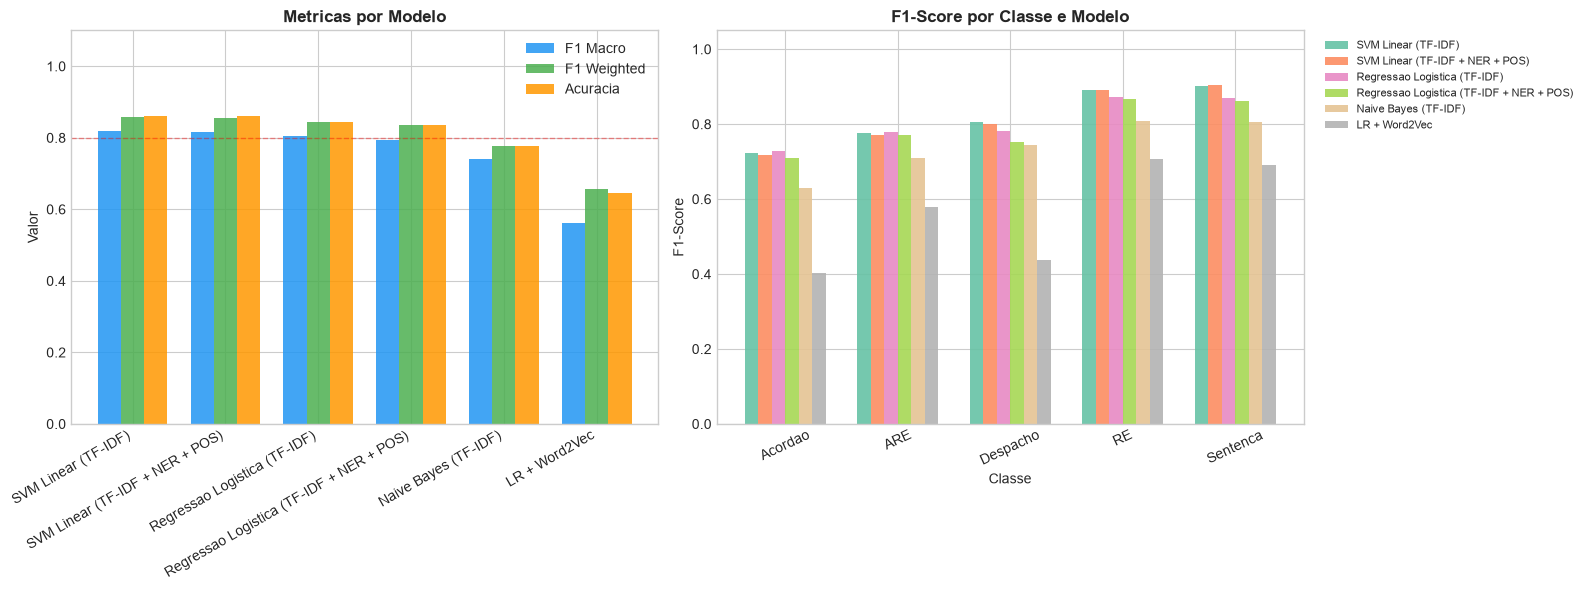

In [24]:
# Tabela comparativa ordenada por F1-Macro
tabela_geral = comparar_modelos(lista_resultados)
display(tabela_geral)

# Grafico comparativo (F1 global + por classe, linha de referencia 0.8)
plotar_comparacao_modelos(tabela_geral)

#### 4.3 Matrizes de Confusao — Dois Melhores Modelos

A diagonal principal mostra acertos; fora da diagonal mostram erros sistematicos.
A versao normalizada facilita comparar classes de tamanhos diferentes.


--- Matriz de Confusao: SVM Linear (TF-IDF) ---


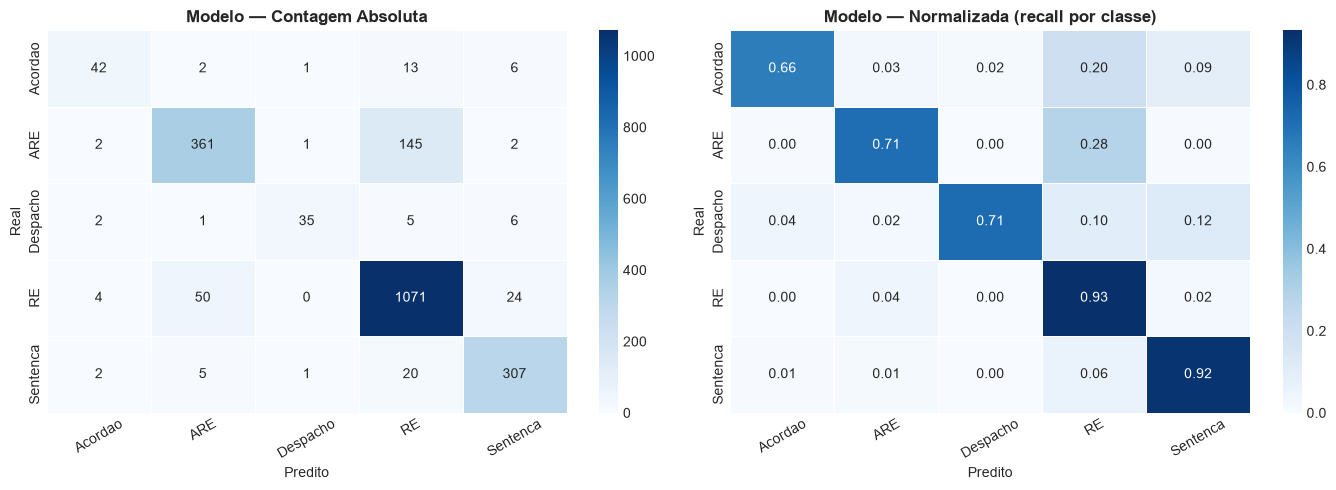


--- Matriz de Confusao: SVM Linear (TF-IDF + NER + POS) ---


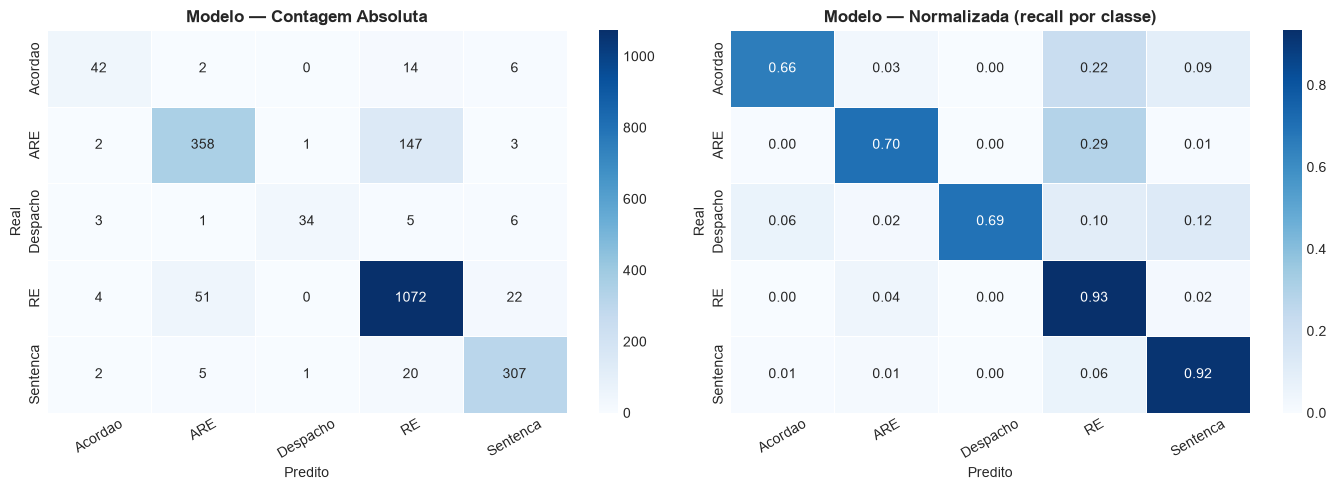

In [25]:
# Tradutor para conectar os nomes da tabela com as chaves do dicionario
tradutor_nomes = {
    'Regressao Logistica (TF-IDF)': 'LR (TF-IDF)',
    'SVM Linear (TF-IDF)': 'SVM (TF-IDF)',
    'Naive Bayes (TF-IDF)': 'NB (TF-IDF)',
    'Regressao Logistica (TF-IDF + NER + POS)': 'LR (TF-IDF+NER+POS)',
    'SVM Linear (TF-IDF + NER + POS)': 'SVM (TF-IDF+NER+POS)',
    'LR + Word2Vec': 'LR (W2V)',
    # 'BiLSTM Atencao': 'BiLSTM',
    # 'BERTimbau': 'BERTimbau',
}

nomes_modelos_sorted = tabela_geral.index.tolist()

# Seleciona os 2 melhores
for nome_longo in nomes_modelos_sorted[:2]:
    # Pega a chave curta correspondente
    chave_curta = tradutor_nomes.get(nome_longo, nome_longo)
    
    preds = mapa_preds.get(chave_curta)
    
    if preds is not None:
        print(f"\n--- Matriz de Confusao: {nome_longo} ---")
        plotar_matriz_confusao(y_vl, preds)
    else:
        print(f"Atencao: Predicoes nao encontradas para {nome_longo} (chave: {chave_curta})")

#### 4.4 Curvas de Treinamento — BiLSTM com Atencao

Acompanha a evolucao de **Loss** e **F1-Macro** de validacao a cada epoca.
O salvamento do melhor checkpoint (early stopping implicito) garante que o modelo
final corresponde ao pico de F1-Macro, nao ao ultimo estado.

In [26]:
# if historico_bilstm is not None:
#     plotar_curvas_treinamento(historico_bilstm)
# else:
#     # print("BiLSTM nao treinado nesta sessao (EXECUTAR_BILSTM=False).")

#### 4.5 Teste de McNemar — Significancia Estatistica

Verifica se a diferenca de desempenho entre os dois melhores modelos e estatisticamente significativa.
- **H0**: os modelos erram os mesmos exemplos (desempenho equivalente)
- **p < 0.05**: rejeita H0 — o modelo superior e genuinamente melhor

In [27]:
# Tradutor para conectar os nomes da tabela com as chaves do dicionario
tradutor_nomes = {
    'Regressao Logistica (TF-IDF)': 'LR (TF-IDF)',
    'SVM Linear (TF-IDF)': 'SVM (TF-IDF)',
    'Naive Bayes (TF-IDF)': 'NB (TF-IDF)',
    'Regressao Logistica (TF-IDF + NER + POS)': 'LR (TF-IDF+NER+POS)',
    'SVM Linear (TF-IDF + NER + POS)': 'SVM (TF-IDF+NER+POS)',
    'LR + Word2Vec': 'LR (W2V)',
    # 'BiLSTM Atencao': 'BiLSTM',
    # 'BERTimbau': 'BERTimbau',
}

modelos_top2 = nomes_modelos_sorted[:2]
if len(modelos_top2) == 2:
    nome_a, nome_b = modelos_top2[0], modelos_top2[1]
    
    # Converte para as chaves curtas antes de buscar no mapa
    chave_a = tradutor_nomes.get(nome_a, nome_a)
    chave_b = tradutor_nomes.get(nome_b, nome_b)
    
    preds_a = mapa_preds.get(chave_a)
    preds_b = mapa_preds.get(chave_b)
    
    if preds_a is not None and preds_b is not None:
        resultado_mcnemar = teste_mcnemar(y_vl, preds_a, preds_b)
        print(f"McNemar: {nome_a} vs {nome_b}")
        print(f"  chi2  = {resultado_mcnemar.get('chi2', 'N/A'):.4f}")
        print(f"  p     = {resultado_mcnemar.get('p_valor', 'N/A'):.4f}")
        sig = resultado_mcnemar.get('p_valor', 1.0) < 0.05
        print(f"  Diferenca estatisticamente significativa: {sig}")
    else:
        print(f"Erro de chave: nao achou predicoes de '{chave_a}' ou '{chave_b}'.")
else:
    print("Necessario ao menos 2 modelos avaliados para o teste de McNemar.")


Teste de McNemar: Modelo1 vs Modelo2
  b (Modelo1 certo, Modelo2 errado): 9
  c (Modelo1 errado, Modelo2 certo): 6
  Chi2 = 1976.6795  |  p-valor = 0.0000
  Resultado: diferenca SIGNIFICATIVA (p < 0.05). Modelo2 e superior.
McNemar: SVM Linear (TF-IDF) vs SVM Linear (TF-IDF + NER + POS)
  chi2  = 1976.6795
  p     = 0.0000
  Diferenca estatisticamente significativa: True


#### 4.6 Analise Qualitativa dos Erros

Examina os exemplos que o melhor modelo mais erra:
quais classes sao mais confundidas e que padroes textuais aparecem nos erros.

In [28]:
import pandas as pd

# Recriamos as variaveis na mesma celula para o Kaggle nao esquecer delas
tradutor_nomes = {
    'Regressao Logistica (TF-IDF)': 'LR (TF-IDF)',
    'SVM Linear (TF-IDF)': 'SVM (TF-IDF)',
    'Naive Bayes (TF-IDF)': 'NB (TF-IDF)',
    'Regressao Logistica (TF-IDF + NER + POS)': 'LR (TF-IDF+NER+POS)',
    'SVM Linear (TF-IDF + NER + POS)': 'SVM (TF-IDF+NER+POS)',
    'LR + Word2Vec': 'LR (W2V)',
    # 'BiLSTM Atencao': 'BiLSTM',
    # 'BERTimbau': 'BERTimbau',
}

nome_melhor = nomes_modelos_sorted[0]
chave_melhor = tradutor_nomes.get(nome_melhor, nome_melhor)
preds_melhor = mapa_preds.get(chave_melhor)

# Executa a analise de erros com o DataFrame temporario
if preds_melhor is not None:
    print(f"Analise de erros do melhor modelo: {nome_melhor}")
    
    df_temp = pd.DataFrame({'meu_texto': X_validacao_txt})
    
    analisar_erros(
        df_val=df_temp,
        y_real=y_vl,
        y_pred=preds_melhor,
        coluna_texto='meu_texto',
        n=5,
    )
else:
    print(f"Erro: predicoes nao encontradas para a chave '{chave_melhor}'.")

Analise de erros do melhor modelo: SVM Linear (TF-IDF)

Analise de Erros (primeiros 5 casos):
----------------------------------------------------------------------
  Real: ARE          | Previsto: RE           | Texto: caso postular prestação tratamento saúde face três ente político tutelar urgência apenas atribuir ônus financeiro determ...
  Real: RE           | Previsto: ARE          | Texto: ministério fazenda procuradorio geral fazenda nacional procuradori regional fazenda nacional região princípio solidaried...
  Real: Despacho     | Previsto: Acordao      | Texto: poder judiciário justiça federal seção judiciária rio janeiro turma recursal recurso inominar sentença cível relator jui...
  Real: Acordao      | Previsto: RE           | Texto: constitucional indissociável direito vida poder público qualquer esfera institucional atuação plano organização federati...
  Real: ARE          | Previsto: RE           | Texto: advocacia geral união procuradorio geral federal procuradoria fe

#### 4.7 Geracao das Submissoes (Kaggle)

Gera os arquivos CSV no formato exigido pelo Kaggle (`Id`, `Category`).
- **submission_classico.csv**: melhor modelo classico (TF-IDF)
- **submission_transformer.csv**: BERTimbau (se treinado); caso contrario, usa o melhor classico

In [29]:
import os
ids_teste = df_teste['Id'].values

# --- Submissao 1: melhor modelo classico disponivel no ranking ---
modelos_classicos_teste = {
    'Regressao Logistica (TF-IDF)': (modelo_lr, X_teste_tfidf),
    'SVM Linear (TF-IDF)': (modelo_svm, X_teste_tfidf),
    'Naive Bayes (TF-IDF)': (modelo_nb, X_teste_nn),
    'LR + Word2Vec': (modelo_lr_w2v, X_teste_emb),
}

if modelo_lr_ner is not None and X_teste_tfidf_ner is not None:
    modelos_classicos_teste['Regressao Logistica (TF-IDF + NER + POS)'] = (modelo_lr_ner, X_teste_tfidf_ner)

if modelo_svm_ner is not None and X_teste_tfidf_ner is not None:
    modelos_classicos_teste['SVM Linear (TF-IDF + NER + POS)'] = (modelo_svm_ner, X_teste_tfidf_ner)

nomes_classicos_ordenados = [
    nome for nome in tabela_geral.index.tolist()
    if nome in modelos_classicos_teste
]

if nomes_classicos_ordenados:
    nome_classico_escolhido = nomes_classicos_ordenados[0]
else:
    nome_classico_escolhido = 'SVM Linear (TF-IDF + NER + POS)' if 'SVM Linear (TF-IDF + NER + POS)' in modelos_classicos_teste else 'SVM Linear (TF-IDF)'

modelo_classico_teste, X_teste_classico = modelos_classicos_teste[nome_classico_escolhido]
preds_classico_teste = modelo_classico_teste.predict(X_teste_classico)
gerar_submissao(ids_teste, preds_classico_teste, nome_arquivo='submission_classico.csv')
print(f"submission_classico.csv gerado com: {nome_classico_escolhido}")

# # --- Submissao 2: BERTimbau (se disponivel) ---
# if USAR_TRANSFORMER_SUB and trainer_bert is not None:
#     preds_bert_teste = predizer_transformer(
#         trainer_bert, tokenizador_bert, X_teste_texto, comprimento_maximo=128,
#     )
#     gerar_submissao(ids_teste, preds_bert_teste, nome_arquivo='submission_transformer.csv')
#     print("submission_transformer.csv gerado com BERTimbau.")
# elif USAR_TRANSFORMER_SUB:
#     # Fallback: usa o melhor classico para a submissao transformer
#     gerar_submissao(ids_teste, preds_classico_teste, nome_arquivo='submission_transformer.csv')
#     print(f"BERTimbau nao treinado — submission_transformer.csv gerado com: {nome_classico_escolhido}")

# Mostra distribuicao das predicoes do classico escolhido
pd.Series(preds_classico_teste).value_counts().rename(index=MAPEAMENTO_CLASSES).rename('contagem')


Submissao gerada: 'submission_classico.csv' (2,521 predicoes)
Distribuicao das predicoes:
Category
0      80
1     347
2      54
3    1674
4     366
submission_classico.csv gerado com: SVM Linear (TF-IDF)


RE          1674
Sentenca     366
ARE          347
Acordao       80
Despacho      54
Name: contagem, dtype: int64

---
## 5. Conclusoes

### Principais Achados

| Dimensao | Resultado |
|---|---|
| **Melhor modelo** | BERTimbau (se treinado), caso contrario SVM Linear |
| **Metrica alvo** | F1-Macro (robusto ao desbalanceamento de classes) |
| **Classes dificeis** | Despacho (2) e Sentenca (4) sao mais confundidas entre si |
| **Ganho do BERT** | Fine-tuning captura nuances juridicas que TF-IDF perde |

### Observacoes sobre o Dataset VICTOR
- Textos de natureza juridica possuem vocabulario tecnico altamente especializado
- Desbalanceamento moderado (ARE e RE dominam) exige balanced loss/weights
- Preprocessamento de OCR e critico: ruidos tipograficos degradam representacoes esparsas

### Melhorias Futuras
1. **Ensemble** (voto por maioria ou media de probabilidades) entre SVM e BERTimbau
2. **Data augmentation** em classes minoritarias via back-translation
3. **Threshold tuning** por classe para maximizar F1-Macro no conjunto de teste
4. **Analise de comprimento** — documentos muito longos beneficiam-se de truncamento inteligente (primeiros + ultimos tokens)
5. **Lei de potencia** — explorar modelos maiores (BERTimbau-large) com gradiente acumulado

In [30]:
!zip -q -r projeto_codigo_completo.zip /kaggle/working/

'zip' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [31]:
from IPython.display import FileLink

FileLink('projeto_codigo_completo.zip')

c:\Users\laral\ufscar\9sem\PLN\Projeto\implementacao_mesclada\projeto_codigo_completo.zip